In [9]:
import yfinance as yf
import pandas as pd
from IPython.display import display, HTML
import math
display(HTML("<style>.container { width:90% ! important; }</style>"))

import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [19]:
#cob_date = '2025-04-01'  # Change this to the desired date

cob_date = '2025-12-31'  # Change this to the desired date

#cob_date = datetime.today().strftime('%Y-%m-%d')
cob_date_dt = datetime.strptime(cob_date, '%Y-%m-%d')
year_end_date = (cob_date_dt).replace(day=1, month=1)

print(f"Calculating for COB date: {cob_date}")
print(f"Year end date derived from COB date: {year_end_date.strftime('%Y-%m-%d')}")

Calculating for COB date: 2025-12-31
Year end date derived from COB date: 2025-01-01


In [20]:
indices_df = pd.read_csv('../data/indian_indices_list.csv')
indices_df.head()

,Category,Name,Ticker,Description
0,market,S&P BSE SENSEX,^BSESN,Benchmark index of BSE (Top 30 companies)
1,market,Nifty 50,^NSEI,Benchmark index of NSE (Top 50 companies)
2,market,Nifty Next 50,^NSMIDCP,The 50 companies after Nifty 50
3,market,Nifty 100,^CNX100,Top 100 companies by market cap
4,sector,Nifty Financial Services,NIFTY_FIN_SERVICE.NS,"Includes banks, NBFCs, and insurance (Finnifty)"


In [21]:
ticker_name_map = indices_df.set_index('Ticker')['Name'].to_dict()
#ticker_name_map
ticker_name_map["^NSEI"]

'Nifty 50'

In [22]:
index_types_list = indices_df['Category'].unique().tolist()
index_types_list

['market', 'sector', 'comm']

In [23]:
index_ticker_map = {}
for index_type in index_types_list:
    tickers = indices_df[indices_df['Category'] == index_type]['Ticker'].tolist()
    index_ticker_map[index_type] = tickers
index_ticker_map

{'market': ['^BSESN', '^NSEI', '^NSMIDCP', '^CNX100', '^CRSLDX'],
 'sector': ['NIFTY_FIN_SERVICE.NS',
  '^NSEBANK',
  '^CNXIT',
  '^CNXPSE',
  '^CNXPHARMA',
  '^CNXAUTO',
  '^CNXFMCG',
  '^CNXPSUBANK',
  '^CNXREALTY',
  '^CNXENERGY',
  '^CNXINFRA',
  '^CNXMEDIA',
  'NIFTY_PVT_BANK.NS'],
 'comm': ['^CNXCMDT', '^CNXMETAL']}

In [24]:
def fetch_data(tickers, start_dt, end_dt):
    df = yf.download(tickers, start=start_dt, end=end_dt)
    df = df['Close']
    return df

In [25]:
dashboard_data = {}
for  ix_type, tickers in index_ticker_map.items():
    dashboard_data[ix_type] = fetch_data(tickers, start_dt = f"{year_end_date.strftime('%Y-%m-%d')}", end_dt=cob_date)

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  13 of 13 completed
[*********************100%***********************]  2 of 2 completed


In [26]:
#dashboard_data.keys()
dashboard_data['market'].head()

Ticker,^BSESN,^CNX100,^CRSLDX,^NSEI,^NSMIDCP
Date,,,,,
2025-01-01,78507.406250,NaN,NaN,23742.900391,NaN
2025-01-02,79943.710938,25028.800781,22819.750000,24188.650391,69103.601562
2025-01-03,79223.109375,24879.849609,22708.150391,24004.750000,69192.453125
2025-01-06,77964.992188,24404.599609,22225.400391,23616.050781,66996.796875
2025-01-07,78199.109375,24478.099609,22341.650391,23707.900391,66938.898438


Asset Class: market


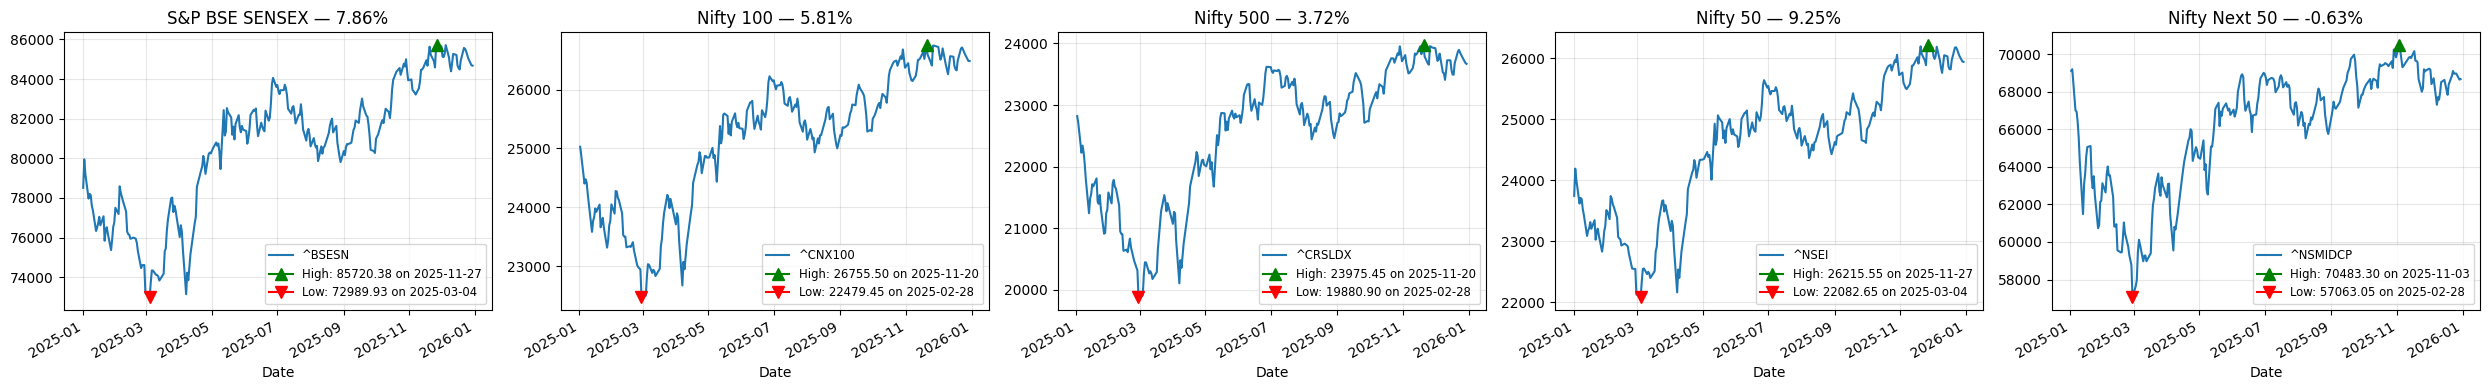

Asset Class: sector


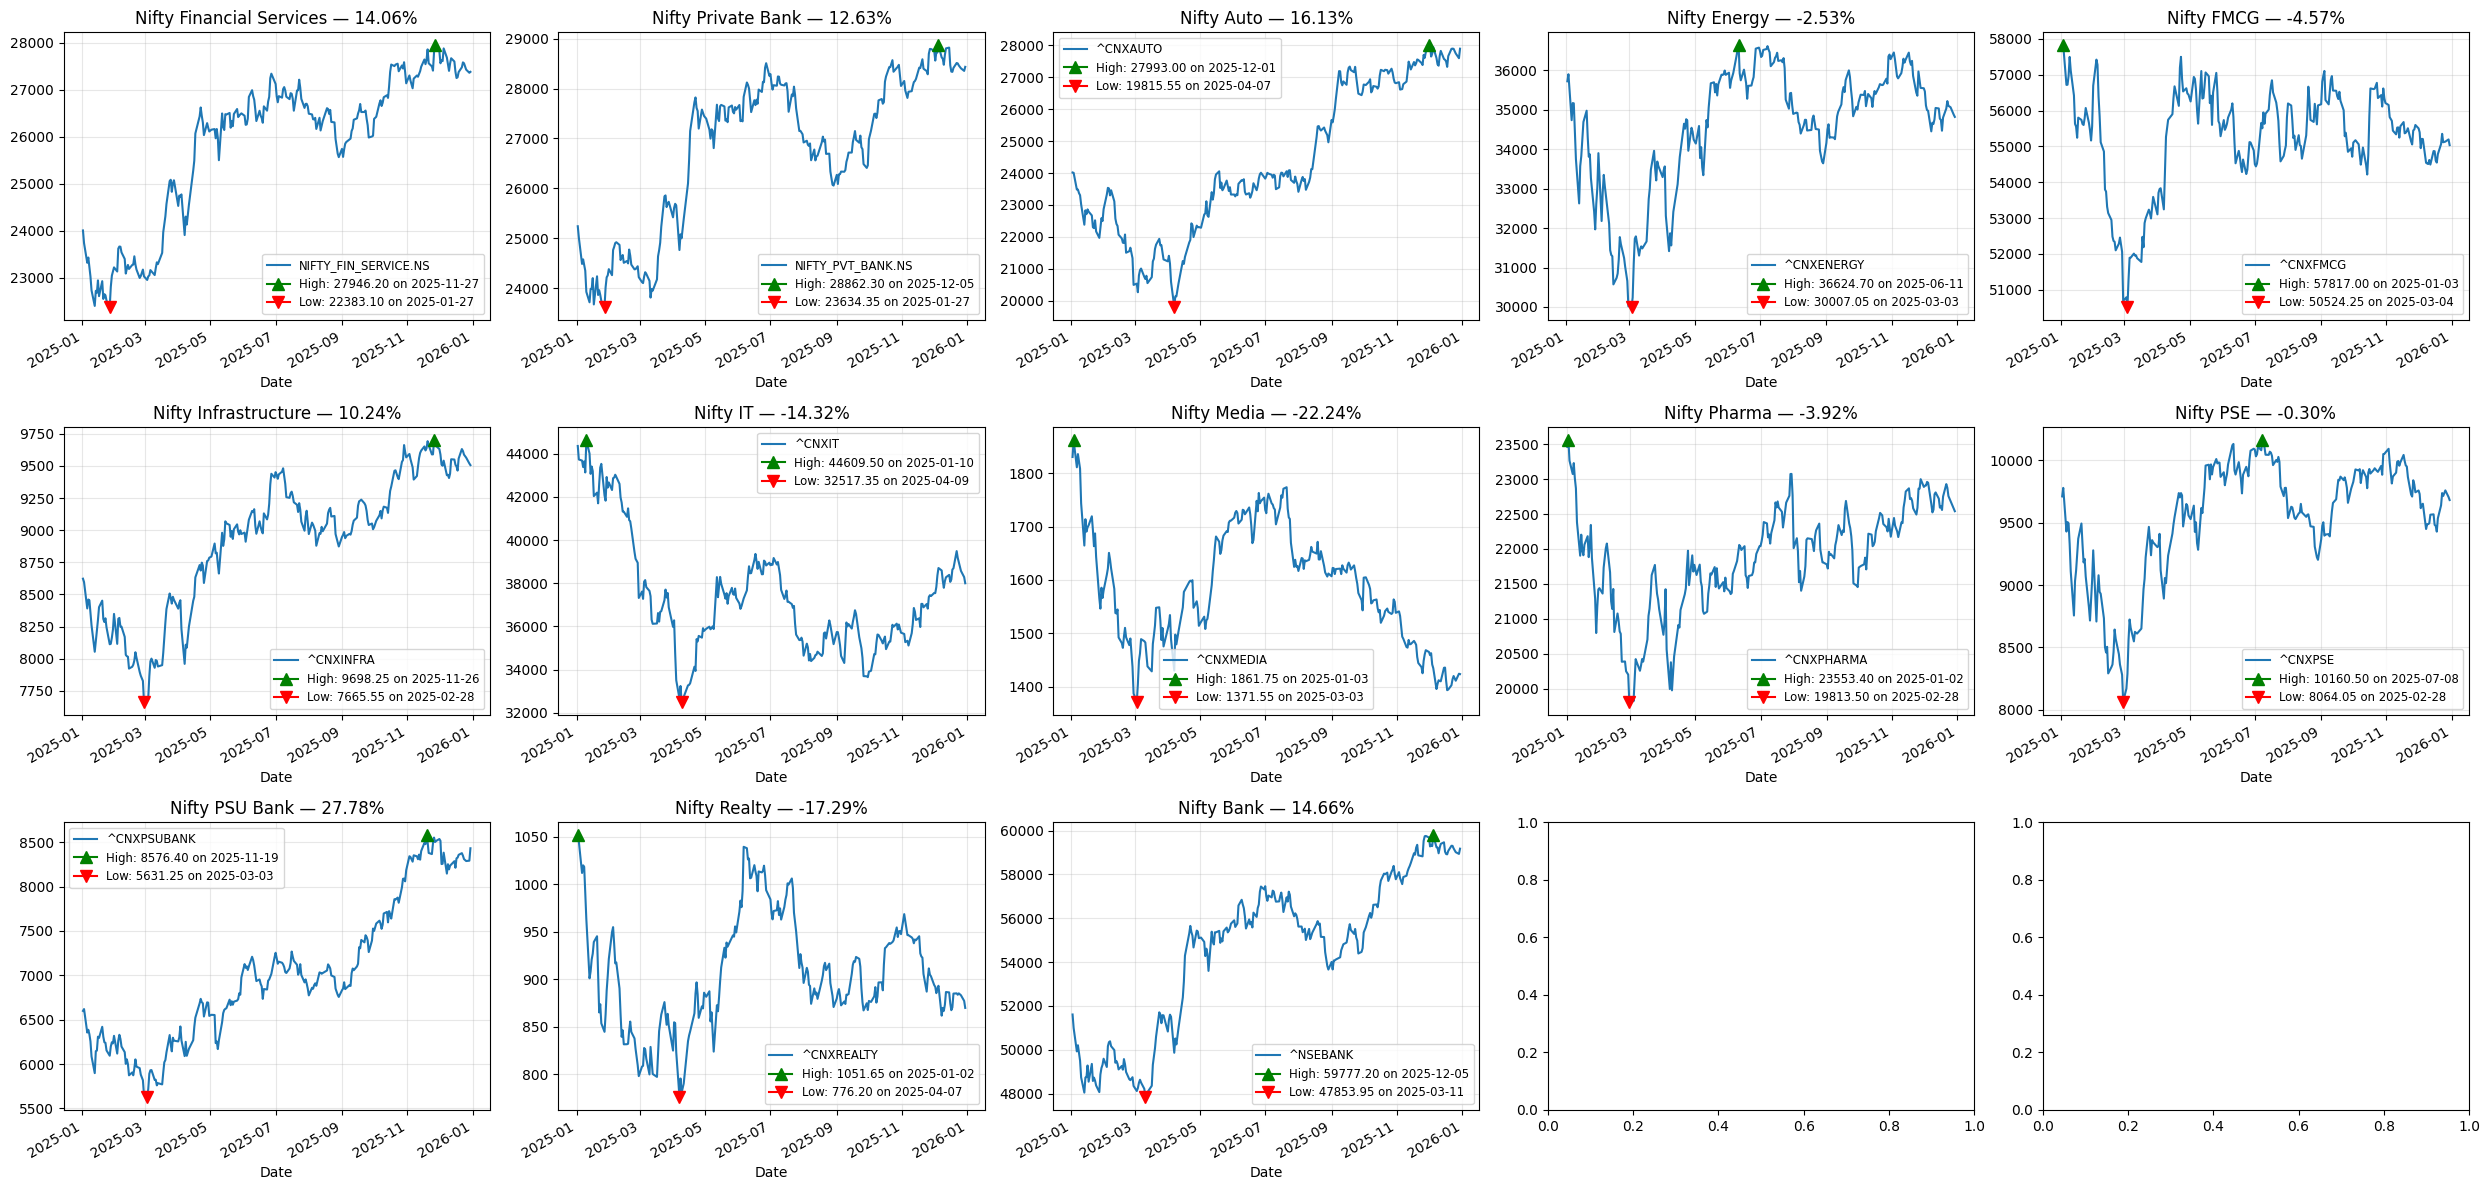

Asset Class: comm


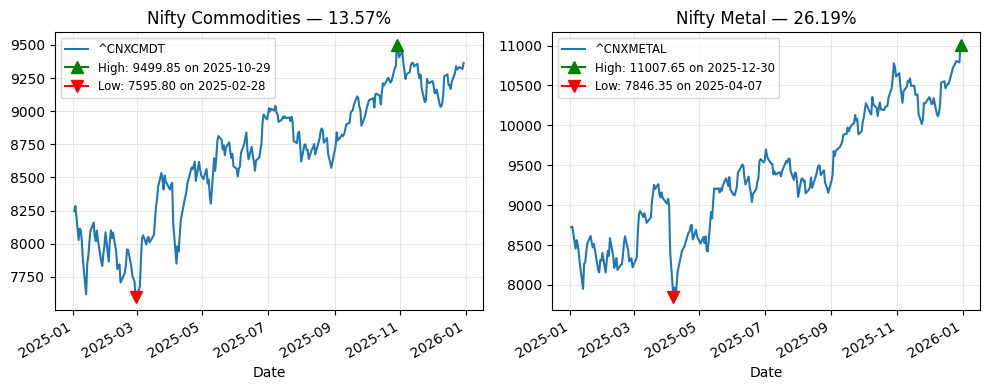

In [27]:
# Display data and charts
for ix_type, df in dashboard_data.items():
    print(f"Asset Class: {ix_type}")

    plot_rows = math.ceil(len(df.columns) / 5)
    plot_cols = min(len(df.columns), 5)
    fig, axes = plt.subplots(ncols=plot_cols, nrows=plot_rows, figsize=(5 * plot_cols, 4 * plot_rows))

    for i, ticker in enumerate(df.columns):
        ax = axes[i] if len(df.columns) <= 5 else axes[i // 5, i % 5]
        series = df[ticker].dropna()
        if series.empty:
            ax.set_title(f"No Data for {ticker}")
            continue

        # Ensure chronological order
        series = series.sort_index()

        # Compute percent return over the period (first available -> last available)
        try:
            start_val = series.iloc[0]
            end_val = series.iloc[-1]
            pct_return = (end_val / start_val - 1) * 100
        except Exception:
            pct_return = float('nan')

        # Plot series with percent return in title
        series.plot(ax=ax, title=f"{ticker_name_map[ticker]} — {pct_return:.2f}%", xlabel=None)

        # Find high and low points
        high_idx = series.idxmax()
        high_val = series.max()
        low_idx = series.idxmin()
        low_val = series.min()

        # Plot markers for high and low
        ax.plot(high_idx, high_val, marker='^', color='green', markersize=8, label=f"High: {high_val:.2f} on {pd.to_datetime(high_idx).strftime('%Y-%m-%d')}")
        ax.plot(low_idx, low_val, marker='v', color='red', markersize=8, label=f"Low: {low_val:.2f} on {pd.to_datetime(low_idx).strftime('%Y-%m-%d')}")

        # Add legend and grid
        ax.legend(fontsize='small')
        ax.grid(alpha=0.3)

    plt.tight_layout()  # Adjust subplot spacing
    plt.show()